In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('nigeria_houses_data.csv')
df

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0
...,...,...,...,...,...,...,...,...
24321,2.0,2.0,2.0,4.0,Block of Flats,Kabusa,Abuja,15000000.0
24322,4.0,5.0,5.0,4.0,Block of Flats,Ado-Odo/Ota,Ogun,25000000.0
24323,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,68000000.0
24324,3.0,4.0,4.0,3.0,Block of Flats,Victoria Island (VI),Lagos,78000000.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  str    
 5   town           24326 non-null  str    
 6   state          24326 non-null  str    
 7   price          24326 non-null  float64
dtypes: float64(5), str(3)
memory usage: 2.1 MB


In [4]:
df.describe()

,bedrooms,bathrooms,toilets,parking_space,price
count,24326.000000,24326.000000,24326.000000,24326.000000,2.432600e+04
mean,4.338814,4.600798,5.176355,4.041725,3.013802e+08
std,1.138497,1.163161,1.226253,1.399936,1.220403e+10
min,1.000000,1.000000,1.000000,1.000000,9.000000e+04
25%,4.000000,4.000000,5.000000,4.000000,5.200000e+07
50%,4.000000,5.000000,5.000000,4.000000,8.500000e+07
75%,5.000000,5.000000,6.000000,4.000000,1.600000e+08
max,9.000000,9.000000,9.000000,9.000000,1.800000e+12


In [5]:
df.shape

(24326, 8)

In [6]:
df.isnull().sum()

bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64

In [7]:
df.shape

(24326, 8)

In [8]:
df.corr(numeric_only=True)

,bedrooms,bathrooms,toilets,parking_space,price
bedrooms,1.000000,0.726557,0.610501,0.158528,0.025734
bathrooms,0.726557,1.000000,0.719102,0.174129,0.021965
toilets,0.610501,0.719102,1.000000,0.225345,0.015486
parking_space,0.158528,0.174129,0.225345,1.000000,0.018370
price,0.025734,0.021965,0.015486,0.018370,1.000000


<Axes: >

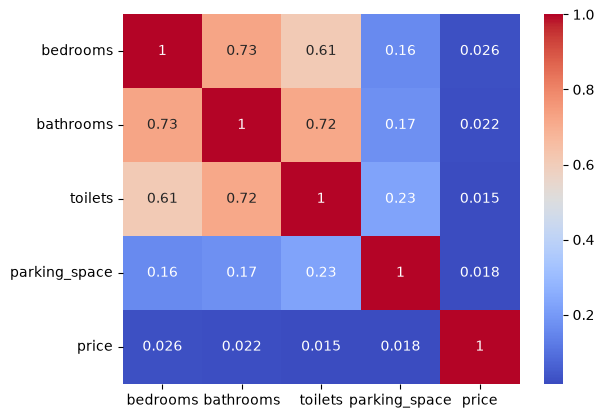

In [9]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

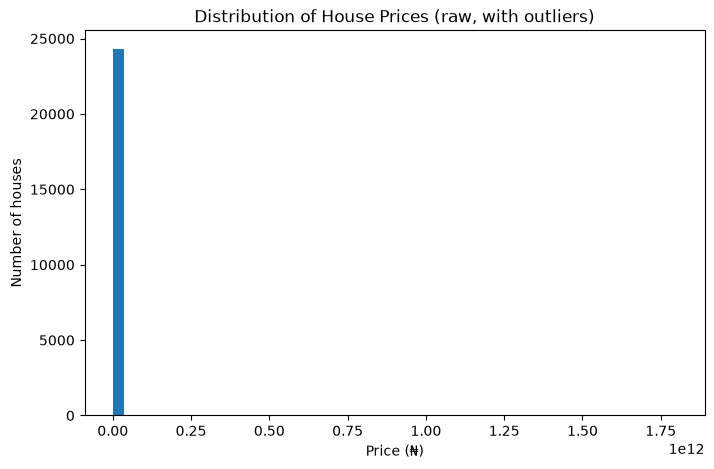

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.xlabel('Price (₦)')
plt.ylabel('Number of houses')
plt.title('Distribution of House Prices (raw, with outliers)')
plt.show()

In [ ]:
df.sort_values('price', ascending=False).head(10)

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
4096,7.0,7.0,8.0,8.0,Detached Duplex,Ikoyi,Lagos,1.800000e+12
6632,4.0,4.0,5.0,4.0,Semi Detached Duplex,Ikoyi,Lagos,4.500000e+11
15962,9.0,9.0,1.0,4.0,Detached Duplex,Lekki,Lagos,3.500000e+11
4327,5.0,5.0,6.0,4.0,Detached Duplex,Lekki,Lagos,1.600000e+11
7098,5.0,5.0,6.0,4.0,Semi Detached Duplex,Lekki,Lagos,1.250000e+11
15836,5.0,6.0,7.0,4.0,Terraced Duplexes,Guzape District,Abuja,8.500000e+10
15806,5.0,5.0,5.0,1.0,Detached Duplex,Ifako-Ijaiye,Lagos,5.500000e+10
17383,4.0,4.0,5.0,3.0,Detached Duplex,Ajah,Lagos,5.000000e+10
13490,3.0,3.0,3.0,4.0,Semi Detached Duplex,Ajah,Lagos,4.200000e+10
20602,4.0,5.0,5.0,4.0,Block of Flats,Ikoyi,Lagos,1.500000e+10


In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:,.0f}")
print(f"Upper bound: {upper_bound:,.0f}")

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")

Lower bound: -110,000,000
Upper bound: 322,000,000
Number of outliers: 2558


In [ ]:
df.sort_values('price', ascending=False).head(30)

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
4096,7.0,7.0,8.0,8.0,Detached Duplex,Ikoyi,Lagos,1.800000e+12
6632,4.0,4.0,5.0,4.0,Semi Detached Duplex,Ikoyi,Lagos,4.500000e+11
15962,9.0,9.0,1.0,4.0,Detached Duplex,Lekki,Lagos,3.500000e+11
4327,5.0,5.0,6.0,4.0,Detached Duplex,Lekki,Lagos,1.600000e+11
7098,5.0,5.0,6.0,4.0,Semi Detached Duplex,Lekki,Lagos,1.250000e+11
15836,5.0,6.0,7.0,4.0,Terraced Duplexes,Guzape District,Abuja,8.500000e+10
15806,5.0,5.0,5.0,1.0,Detached Duplex,Ifako-Ijaiye,Lagos,5.500000e+10
17383,4.0,4.0,5.0,3.0,Detached Duplex,Ajah,Lagos,5.000000e+10
13490,3.0,3.0,3.0,4.0,Semi Detached Duplex,Ajah,Lagos,4.200000e+10
20602,4.0,5.0,5.0,4.0,Block of Flats,Ikoyi,Lagos,1.500000e+10


In [ ]:
df_clean = df[df['price'] < 25_000_000_000].copy()
print(f"Removed {len(df) - len(df_clean)} rows")
df_clean['price'].describe()

Removed 9 rows


count    2.431700e+04
mean     1.733098e+08
std      3.881701e+08
min      9.000000e+04
25%      5.200000e+07
50%      8.500000e+07
75%      1.600000e+08
max      1.500000e+10
Name: price, dtype: float64

In [ ]:
town_counts = df_clean['town'].value_counts()
common_towns = town_counts[town_counts >= 50].index
df_clean['town_grouped'] = df_clean['town'].apply(lambda t: t if t in common_towns else 'Other')

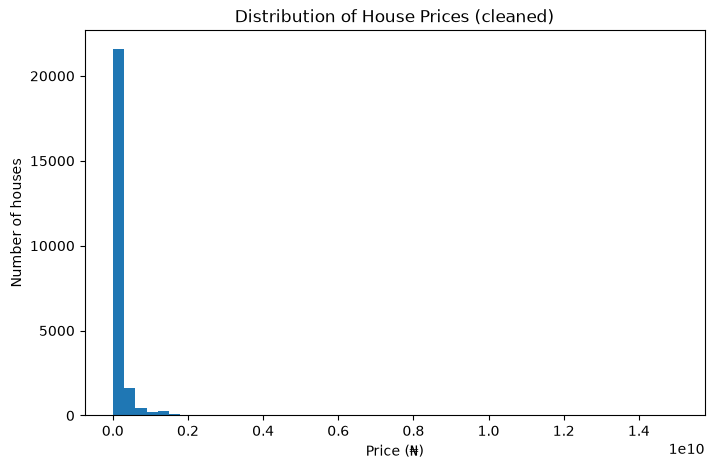

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['price'], bins=50)
plt.xlabel('Price (₦)')
plt.ylabel('Number of houses')
plt.title('Distribution of House Prices (cleaned)')
plt.show()

In [ ]:
df_model = df_clean.drop(columns=['town'])
df_encoded = pd.get_dummies(df_model, columns=['title', 'state', 'town_grouped'], drop_first=True)

In [ ]:
X = df_encoded.drop(columns=['price'])
y = np.log(df_encoded['price'])

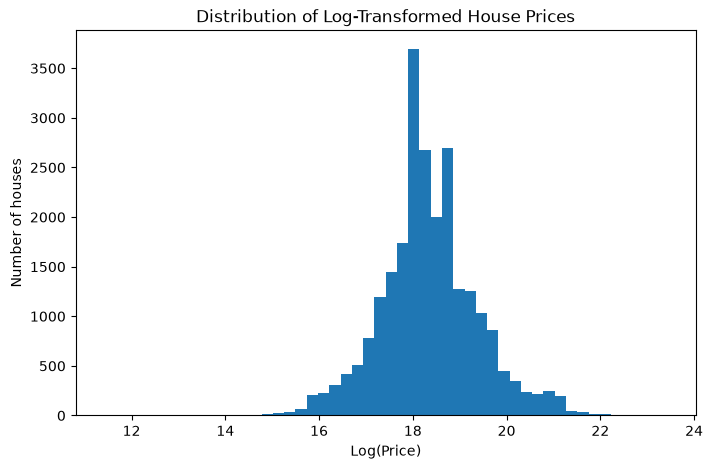

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log(df_clean['price']), bins=50)
plt.xlabel('Log(Price)')
plt.ylabel('Number of houses')
plt.title('Distribution of Log-Transformed House Prices')
plt.show()

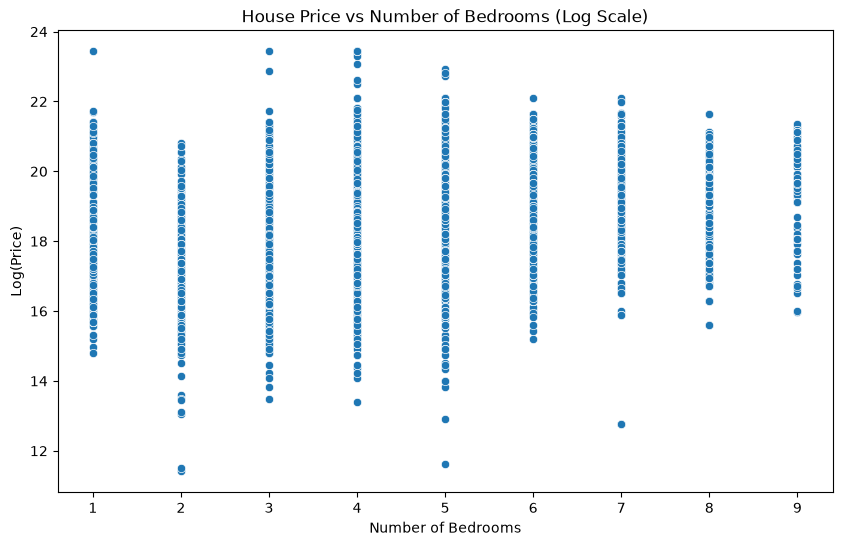

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_clean, x="bedrooms", y=np.log(df_clean["price"]))

plt.title("House Price vs Number of Bedrooms (Log Scale)")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Log(Price)")

plt.show()

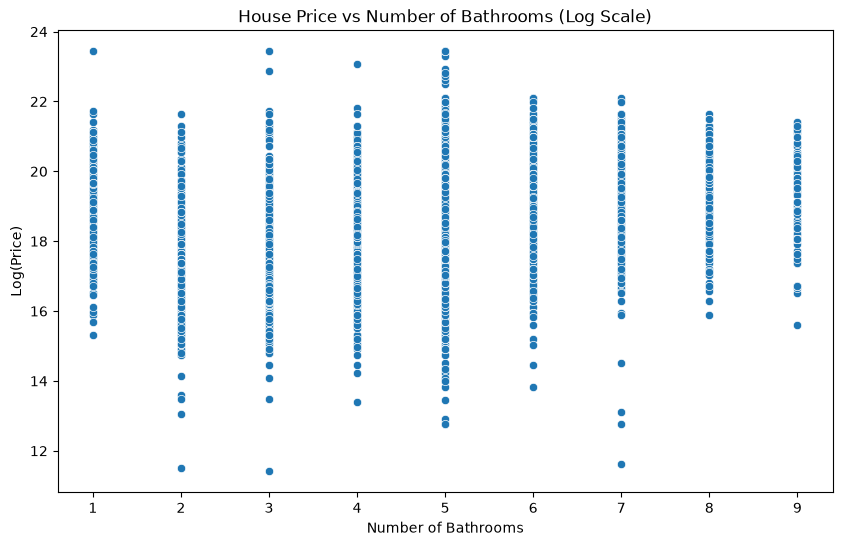

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="bathrooms", y=np.log(df_clean["price"]))
plt.title("House Price vs Number of Bathrooms (Log Scale)")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Log(Price)")
plt.show()

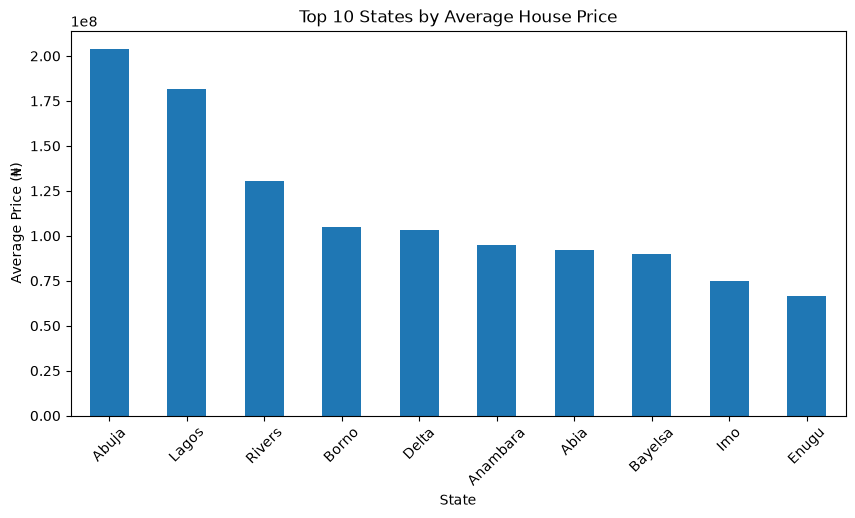

In [ ]:
top_states = df_clean.groupby('state')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Average Price (₦)')
plt.title('Top 10 States by Average House Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('R2:', r2_score(y_test, y_pred))

R2: 0.65640545125403


In [ ]:
df_model

,bedrooms,bathrooms,toilets,parking_space,title,state,price,town_grouped
0,6.0,5.0,5.0,4.0,Detached Duplex,Abuja,450000000.0,Mabushi
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Abuja,800000000.0,Katampe
2,4.0,5.0,5.0,4.0,Detached Duplex,Lagos,120000000.0,Lekki
3,4.0,4.0,5.0,6.0,Detached Duplex,Lagos,40000000.0,Ajah
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lagos,75000000.0,Lekki
...,...,...,...,...,...,...,...,...
24321,2.0,2.0,2.0,4.0,Block of Flats,Abuja,15000000.0,Other
24322,4.0,5.0,5.0,4.0,Block of Flats,Ogun,25000000.0,Other
24323,4.0,5.0,5.0,4.0,Detached Duplex,Lagos,68000000.0,Lekki
24324,3.0,4.0,4.0,3.0,Block of Flats,Lagos,78000000.0,Victoria Island (VI)


In [ ]:
y_test_naira = np.exp(y_test)
y_pred_naira = np.exp(y_pred)

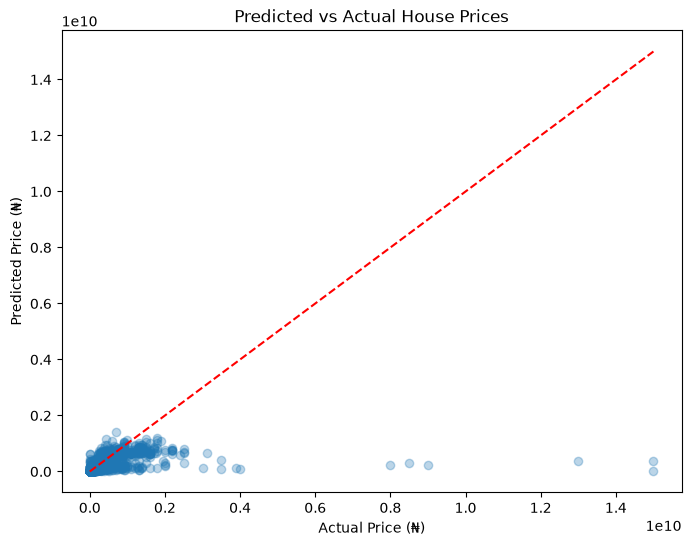

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_naira, y_pred_naira, alpha=0.3)
plt.plot([y_test_naira.min(), y_test_naira.max()], [y_test_naira.min(), y_test_naira.max()], 'r--')
plt.xlabel('Actual Price (₦)')
plt.ylabel('Predicted Price (₦)')
plt.title('Predicted vs Actual House Prices')
plt.show()

Houses under 2B: 7268 out of 7296 test houses
R2 (under 2B only): 0.6142008824650722
MAE (under 2B only): ₦65,046,274


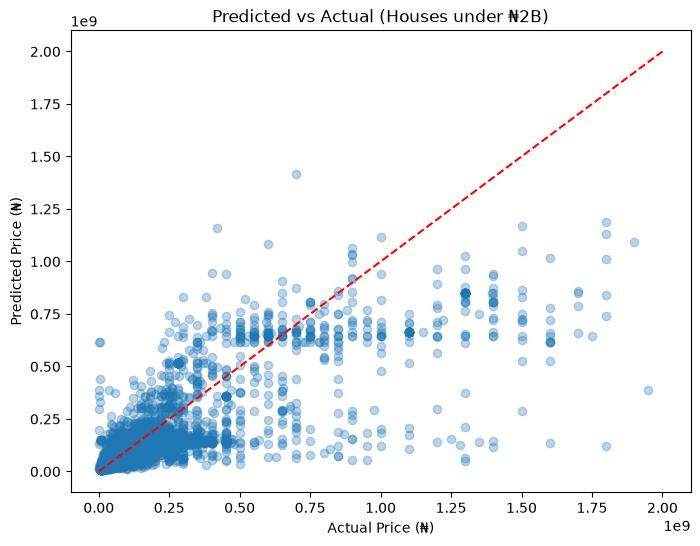

In [ ]:

mask = y_test_naira < 2_000_000_000
print(f'Houses under 2B: {mask.sum()} out of {len(y_test_naira)} test houses')
print(f'R2 (under 2B only):', r2_score(y_test_naira[mask], y_pred_naira[mask]))
print(f'MAE (under 2B only): ₦{mean_absolute_error(y_test_naira[mask], y_pred_naira[mask]):,.0f}')

plt.figure(figsize=(8,6))
plt.scatter(y_test_naira[mask], y_pred_naira[mask], alpha=0.3)
plt.plot([0, 2_000_000_000], [0, 2_000_000_000], 'r--')
plt.xlabel('Actual Price (₦)')
plt.ylabel('Predicted Price (₦)')
plt.title('Predicted vs Actual (Houses under ₦2B)')
plt.show()

In [ ]:
import pickle

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

model_columns = X.columns.tolist()
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

print("Model and columns saved!")

Model and columns saved!
